# RT-DETR WBC Dataset Visualization

This notebook visualizes the Raabin WBC dataset used for training the RT-DETR models.

It shows:
- Polygon segmentation annotations overlaid on images (per class)
- Random samples with bounding boxes derived from polygon labels

> Run this notebook standalone — it does not depend on any training outputs.

## 1. Setup and Imports

In [1]:
%matplotlib inline

import os
import random
from glob import glob

import cv2
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon

plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 72
plt.rcParams['savefig.dpi'] = 72

print("Imports loaded successfully!")

Imports loaded successfully!


## 2. Configuration

In [2]:
NOTEBOOK_DIR = os.getcwd()

# Dataset path
DATA_ROOT  = r"C:\D drive\mydata\MSML\DataSets\Raabin_datsets_withlabels"
IMAGES_DIR = os.path.join(DATA_ROOT, "Train", "images")
LABELS_DIR = os.path.join(DATA_ROOT, "Train", "labels")

# Class definitions
CLASSES = {
    "Basophil":   0,
    "Eosinophil": 1,
    "Lymphocyte": 2,
    "Monocyte":   3,
    "Neutrophil": 4
}
ID2LABEL    = {v: k for k, v in CLASSES.items()}
NUM_CLASSES = len(CLASSES)

print(f"Data root  : {DATA_ROOT}")
print(f"Images dir : {IMAGES_DIR}")
print(f"Labels dir : {LABELS_DIR}")
print(f"Classes    : {list(CLASSES.keys())}")

Data root  : C:\D drive\mydata\MSML\DataSets\Raabin_datsets_withlabels
Images dir : C:\D drive\mydata\MSML\DataSets\Raabin_datsets_withlabels\Train\images
Labels dir : C:\D drive\mydata\MSML\DataSets\Raabin_datsets_withlabels\Train\labels
Classes    : ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


## 3. Visualize Dataset with Polygon Annotations

For each WBC class, a random sample of training images is shown with:
- **Green polygon** — the segmentation mask as annotated in the YOLO polygon label file
- **Red dashed box** — the bounding box derived from the polygon (used by RT-DETR during training)

In [3]:
def visualize_polygon_annotations(images_dir, labels_dir, classes, samples_per_class=3, random_seed=42):
    """
    Visualize polygon segmentation annotations overlaid on images.
    Green = polygon outline, Red dashed = bounding box derived from polygon
    """
    if random_seed is not None:
        random.seed(random_seed)
    
    for cls_name in classes:
        img_cls_dir = os.path.join(images_dir, cls_name)
        lbl_cls_dir = os.path.join(labels_dir, cls_name)
        
        if not os.path.exists(img_cls_dir) or not os.path.exists(lbl_cls_dir):
            print(f"Warning: Directory not found for {cls_name}")
            continue
        
        # Get image files that have matching label files
        image_files = [f for f in os.listdir(img_cls_dir) if f.lower().endswith(".jpg")]
        valid_files = []
        for f in image_files:
            lbl_file = f.replace('.jpg', '.txt').replace('.JPG', '.txt')
            if os.path.exists(os.path.join(lbl_cls_dir, lbl_file)):
                valid_files.append(f)
        
        # Sample random files
        sample_files = random.sample(valid_files, min(samples_per_class, len(valid_files)))
        
        print(f"\n{'='*60}")
        print(f"Class: {cls_name}")
        print(f"{'='*60}")
        
        fig, axes = plt.subplots(1, len(sample_files), figsize=(6*len(sample_files), 6))
        if len(sample_files) == 1:
            axes = [axes]
        
        for idx, img_file in enumerate(sample_files):
            img_path = os.path.join(img_cls_dir, img_file)
            lbl_file = img_file.replace('.jpg', '.txt').replace('.JPG', '.txt')
            lbl_path = os.path.join(lbl_cls_dir, lbl_file)
            
            # Load image
            img = Image.open(img_path).convert("RGB")
            w, h = img.size
            
            # Load polygon annotation
            with open(lbl_path, 'r') as f:
                line = f.readline().strip()
            
            ax = axes[idx]
            ax.imshow(img)
            ax.set_title(f"{img_file}\n({w}x{h})", fontsize=10)
            ax.axis("off")
            
            if line:
                parts = line.split()
                coords = [float(x) for x in parts[1:]]
                
                # Convert normalized coords to pixel coords
                x_coords = [coords[i] * w for i in range(0, len(coords), 2)]
                y_coords = [coords[i] * h for i in range(1, len(coords), 2)]
                
                # Create polygon
                polygon_pts = list(zip(x_coords, y_coords))
                polygon = Polygon(polygon_pts, closed=True, fill=False, 
                                  edgecolor='lime', linewidth=2)
                ax.add_patch(polygon)
                
                # Draw bounding box from polygon
                x_min, x_max = min(x_coords), max(x_coords)
                y_min, y_max = min(y_coords), max(y_coords)
                rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                                         linewidth=2, edgecolor='red', facecolor='none',
                                         linestyle='--')
                ax.add_patch(rect)
                
                # Add legend
                ax.text(5, 20, f"Polygon (green)", color='lime', fontsize=9, 
                       backgroundcolor='black')
                ax.text(5, 40, f"BBox (red dashed)", color='red', fontsize=9,
                       backgroundcolor='black')
        
        plt.tight_layout()
        plt.show()

Visualizing polygon segmentation annotations for each class...
Green = polygon outline, Red dashed = bounding box derived from polygon


Class: Basophil


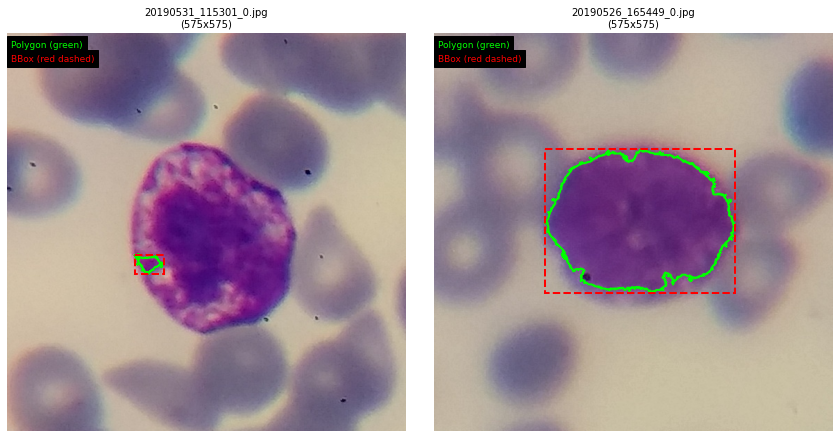


Class: Eosinophil


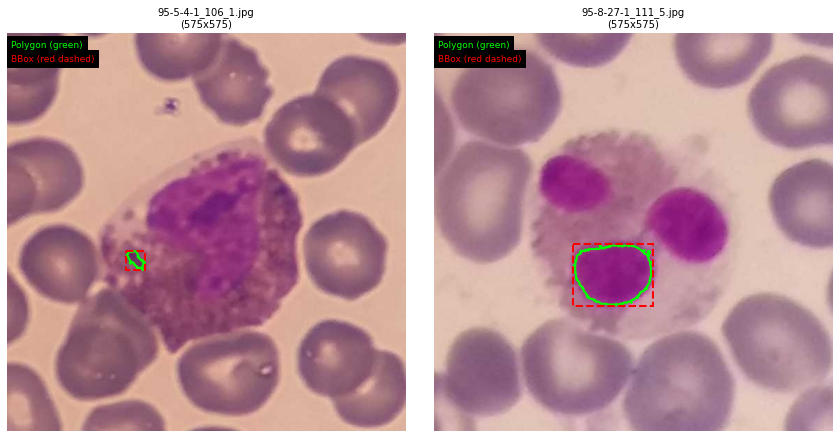


Class: Lymphocyte


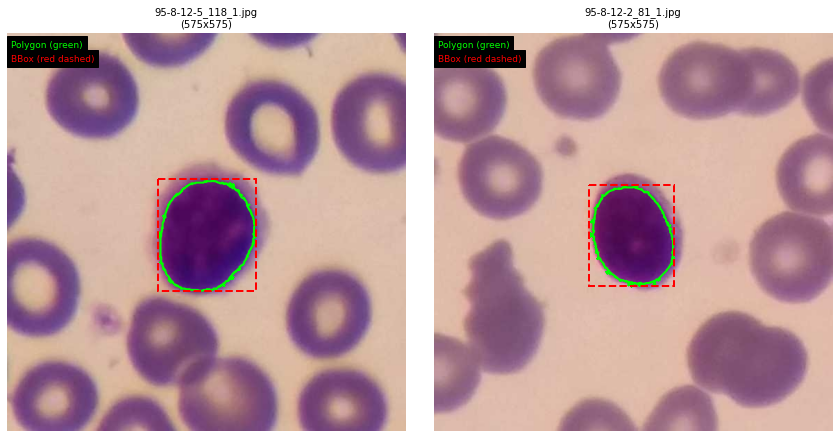


Class: Monocyte


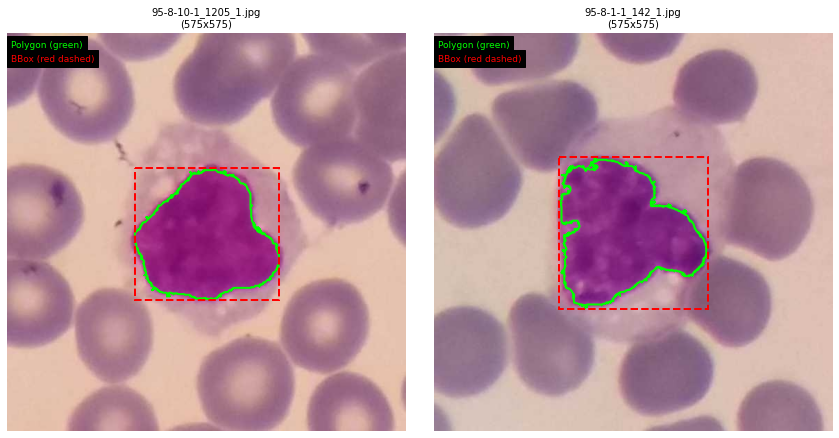


Class: Neutrophil


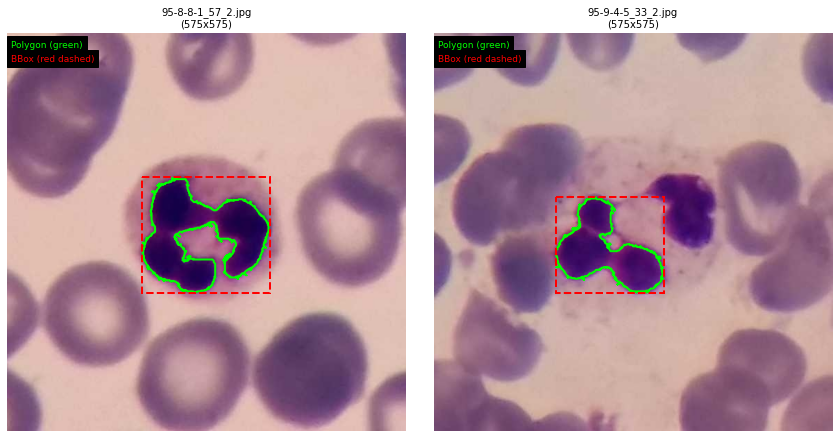

In [4]:
# Visualize polygon annotations for all classes
print("Visualizing polygon segmentation annotations for each class...")
print("Green = polygon outline, Red dashed = bounding box derived from polygon\n")
visualize_polygon_annotations(IMAGES_DIR, LABELS_DIR, list(CLASSES.keys()), samples_per_class=2)

## 4. Visualize Random Samples with Bounding Boxes

A random selection of images across all classes shown with their bounding boxes,
to give a quick sense of image diversity and annotation quality.

In [5]:
def parse_yolo_polygon(label_path, img_width, img_height):
    """
    Parse YOLO polygon annotation and extract bounding box.
    """
    with open(label_path, 'r') as f:
        line = f.readline().strip()

    if not line:
        return [int(0.1 * img_width), int(0.1 * img_height),
                int(0.8 * img_width), int(0.8 * img_height)]

    parts = line.split()
    coords = [float(x) for x in parts[1:]]

    x_coords = [coords[i] for i in range(0, len(coords), 2)]
    y_coords = [coords[i] for i in range(1, len(coords), 2)]

    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)

    x = int(x_min * img_width)
    y = int(y_min * img_height)
    w = int((x_max - x_min) * img_width)
    h = int((y_max - y_min) * img_height)

    return [x, y, w, h]


def visualize_samples(images_dir, labels_dir, classes, n=5, random_seed=None):
    """
    Visualize random samples with bounding boxes from each class.
    """
    if random_seed is not None:
        random.seed(random_seed)

    all_samples = []
    for cls_name, cls_id in classes.items():
        img_cls_dir = os.path.join(images_dir, cls_name)
        lbl_cls_dir = os.path.join(labels_dir, cls_name)
        
        if not os.path.exists(img_cls_dir):
            continue
            
        image_files = [f for f in os.listdir(img_cls_dir) if f.lower().endswith(".jpg")]
        for img_file in image_files:
            lbl_file = img_file.replace('.jpg', '.txt').replace('.JPG', '.txt')
            if os.path.exists(os.path.join(lbl_cls_dir, lbl_file)):
                all_samples.append({
                    "img_path": os.path.join(img_cls_dir, img_file),
                    "lbl_path": os.path.join(lbl_cls_dir, lbl_file),
                    "class_name": cls_name,
                    "class_id": cls_id
                })
    
    samples = random.sample(all_samples, min(n, len(all_samples)))

    for sample in samples:
        img = Image.open(sample["img_path"]).convert("RGB")
        img_width, img_height = img.size
        box = parse_yolo_polygon(sample["lbl_path"], img_width, img_height)
        x, y, w, h = box
        label = sample["class_name"]

        fig, ax = plt.subplots(1, figsize=(6, 6))
        ax.imshow(img)
        ax.axis("off")

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x, y - 5, label, color="red", fontsize=12, backgroundcolor="white")
        ax.set_title(f"Sample: {label}")
        plt.show()

Visualizing random samples with bounding boxes...



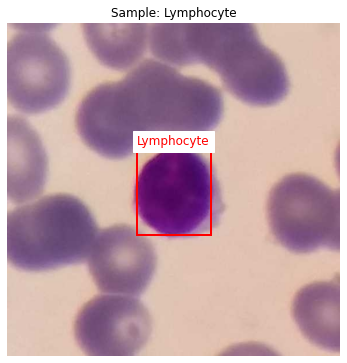

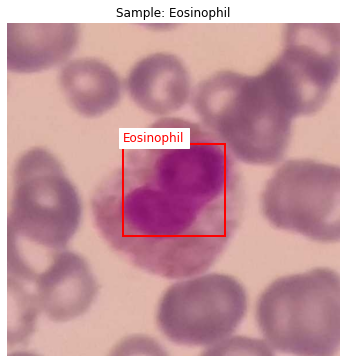

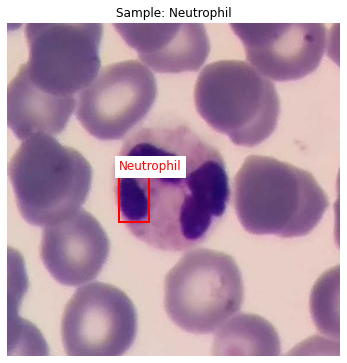

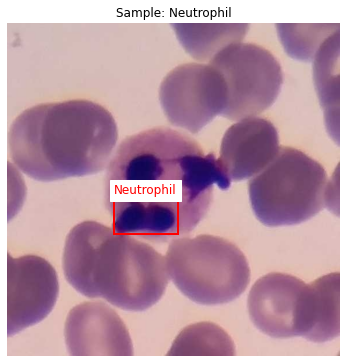

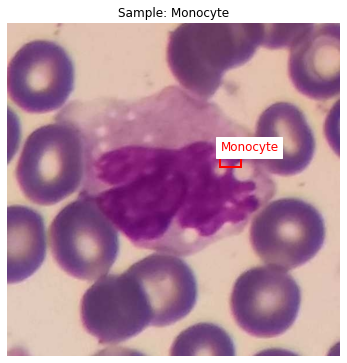

In [9]:
# Visualize random samples with bounding boxes
print("Visualizing random samples with bounding boxes...\n")
visualize_samples(IMAGES_DIR, LABELS_DIR, CLASSES, n=5, random_seed=42)